# Custom Canvas Gesture Shortcut Recognizer

Trains a small CNN to classify hand-drawn canvas gestures (Arrow, Checkmark, Cross, Star). Unlike the sentiment demo, there is no existing labeled dataset for these 4 gesture classes, so this notebook procedurally _generates_ a synthetic labeled dataset by drawing each shape with randomized position, rotation, scale, stroke width, and hand-tremor-like wobble noise.


In [1]:
import os

# Force legacy Keras 2 for tensorflowjs compatibility
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
# Install legacy tensorflow

!pip install tf-keras -q

In [3]:
import json
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image, ImageDraw, ImageFilter
from sklearn.model_selection import train_test_split

In [ ]:
import tf_keras

print(tf_keras.__version__)

2.19.0


## Synthetic Data Generation


In [5]:
IMG_SIZE = 28  # matches the 28x28 tensor the frontend will feed the model
HIRES = 224  # shapes are drawn large, then blurred + downsampled for anti-aliasing
CLASSES = ["Arrow", "Checkmark", "Cross", "Star"]
SAMPLES_PER_CLASS = 600

# Bounded per class so augmentation can't rotate one shape into looking like another
ROTATION_RANGE = {
    "Arrow": (-35, 35),
    "Checkmark": (-20, 20),
    "Cross": (-20, 20),
    "Star": (-180, 180),  # a 5-point star looks plausible at any rotation
}

In [6]:
def _rotate_point(x, y, cx, cy, angle_deg):
    angle = math.radians(angle_deg)
    dx, dy = x - cx, y - cy
    rx = cx + dx * math.cos(angle) - dy * math.sin(angle)
    ry = cy + dx * math.sin(angle) + dy * math.cos(angle)
    return rx, ry


def _subdivide(points, segments_per_edge=6):
    dense = []
    for i in range(len(points) - 1):
        x0, y0 = points[i]
        x1, y1 = points[i + 1]
        for t in range(segments_per_edge):
            frac = t / segments_per_edge
            dense.append((x0 + (x1 - x0) * frac, y0 + (y1 - y0) * frac))
    dense.append(points[-1])
    return dense


def _wobble_line(draw, points, width, wobble=4):
    # Subdivide + jitter every point (not just the anchors) so strokes look like
    # tremor-y hand-drawn lines instead of perfectly straight vector segments.
    dense = _subdivide(points)
    jittered = [
        (x + random.uniform(-wobble, wobble), y + random.uniform(-wobble, wobble))
        for x, y in dense
    ]
    draw.line(jittered, fill=255, width=width, joint="curve")
    for x, y in (jittered[0], jittered[-1]):
        r = width / 2
        draw.ellipse([x - r, y - r, x + r, y + r], fill=255)

In [7]:
def draw_arrow(draw, cx, cy, size, angle, width):
    half = size / 2
    shaft_start = (cx - half, cy)
    shaft_end = (cx + half, cy)
    head_len = size * 0.35
    head1 = (shaft_end[0] - head_len, shaft_end[1] - head_len)
    head2 = (shaft_end[0] - head_len, shaft_end[1] + head_len)
    pts = [shaft_start, shaft_end, head1, shaft_end, head2]
    rotated = [_rotate_point(x, y, cx, cy, angle) for x, y in pts]
    _wobble_line(draw, rotated, width)


def draw_checkmark(draw, cx, cy, size, angle, width):
    half = size / 2
    p1 = (cx - half, cy)
    p2 = (cx - half * 0.2, cy + half * 0.6)
    p3 = (cx + half, cy - half * 0.7)
    rotated = [_rotate_point(x, y, cx, cy, angle) for x, y in (p1, p2, p3)]
    _wobble_line(draw, rotated, width)


def draw_cross(draw, cx, cy, size, angle, width):
    half = size / 2
    diagonals = [
        [(cx - half, cy - half), (cx + half, cy + half)],
        [(cx - half, cy + half), (cx + half, cy - half)],
    ]
    for line in diagonals:
        rotated = [_rotate_point(x, y, cx, cy, angle) for x, y in line]
        _wobble_line(draw, rotated, width)


def draw_star(draw, cx, cy, size, angle, width):
    outer_r = size / 2
    inner_r = outer_r * 0.42
    points = []
    for i in range(10):
        r = outer_r if i % 2 == 0 else inner_r
        theta = math.radians(i * 36 - 90)
        points.append((cx + r * math.cos(theta), cy + r * math.sin(theta)))
    points.append(points[0])
    rotated = [_rotate_point(x, y, cx, cy, angle) for x, y in points]
    _wobble_line(draw, rotated, width)


DRAW_FUNCS = {
    "Arrow": draw_arrow,
    "Checkmark": draw_checkmark,
    "Cross": draw_cross,
    "Star": draw_star,
}

In [8]:
def generate_sample(shape_name):
    """White stroke on black background — must match the canvas convention gesture.js draws with."""
    img = Image.new("L", (HIRES, HIRES), color=0)
    draw = ImageDraw.Draw(img)

    cx = HIRES / 2 + random.uniform(-20, 20)
    cy = HIRES / 2 + random.uniform(-20, 20)
    size = HIRES * random.uniform(0.5, 0.75)
    width = random.randint(10, 18)
    lo, hi = ROTATION_RANGE[shape_name]
    angle = random.uniform(lo, hi)

    DRAW_FUNCS[shape_name](draw, cx, cy, size, angle, width)

    img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(1.0, 2.5)))
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

    arr = np.asarray(img, dtype=np.float32) / 255.0
    noise = np.random.normal(0, 0.03, arr.shape).astype(np.float32)
    return np.clip(arr + noise, 0.0, 1.0)

In [9]:
X, y = [], []
for label_idx, shape_name in enumerate(CLASSES):
    for _ in range(SAMPLES_PER_CLASS):
        X.append(generate_sample(shape_name))
        y.append(label_idx)

X = np.array(X, dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y, dtype=np.int64)

shuffle_idx = np.random.permutation(len(X))
X, y = X[shuffle_idx], y[shuffle_idx]

print(X.shape, y.shape)

(2400, 28, 28, 1) (2400,)


A quick visual sanity check that the synthetic shapes look plausible before spending time training:


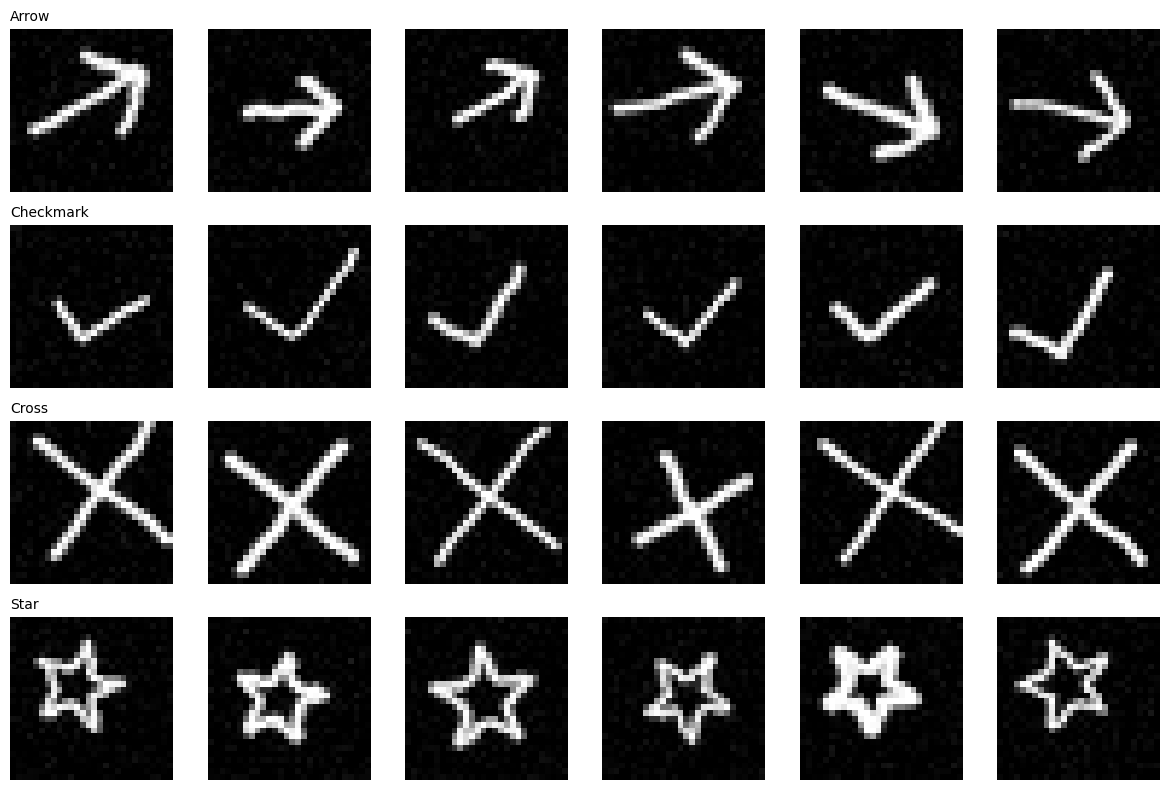

In [10]:
fig, axes = plt.subplots(len(CLASSES), 6, figsize=(12, 8))
for row, shape_name in enumerate(CLASSES):
    idxs = np.where(y == row)[0][:6]
    for col in range(6):
        ax = axes[row, col]
        ax.imshow(X[idxs[col], :, :, 0], cmap="gray")
        ax.axis("off")
    axes[row, 0].set_title(shape_name, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

## Splitting the Dataset


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=10
)

print("Training dataset:\n", X_train.shape, y_train.shape)
print("\nTest dataset:\n", X_test.shape, y_test.shape)

Training dataset:
 (1920, 28, 28, 1) (1920,)

Test dataset:
 (480, 28, 28, 1) (480,)


## Building the Model


In [12]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(len(CLASSES), activation="softmax"),
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1568)              0         
                                                                 
 dense (Dense)               (None, 64)                1

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Training the Model


In [14]:
num_epochs = 25
history = model.fit(
    X_train,
    y_train,
    epochs=num_epochs,
    validation_data=(X_test, y_test),
    verbose=1,
)

Epoch 1/25
60/60 [==============================] - 3s 23ms/step - loss: 0.3985 - accuracy: 0.8719 - val_loss: 0.0458 - val_accuracy: 0.9896
Epoch 2/25
60/60 [==============================] - 1s 20ms/step - loss: 0.0389 - accuracy: 0.9880 - val_loss: 0.0147 - val_accuracy: 0.9937
Epoch 3/25
60/60 [==============================] - 1s 21ms/step - loss: 0.0247 - accuracy: 0.9906 - val_loss: 0.0035 - val_accuracy: 1.0000
Epoch 4/25
60/60 [==============================] - 2s 25ms/step - loss: 0.0154 - accuracy: 0.9943 - val_loss: 0.0036 - val_accuracy: 1.0000
Epoch 5/25
60/60 [==============================] - 1s 22ms/step - loss: 0.0079 - accuracy: 0.9984 - val_loss: 0.0019 - val_accuracy: 1.0000
Epoch 6/25
60/60 [==============================] - 1s 25ms/step - loss: 0.0101 - accuracy: 0.9969 - val_loss: 0.0024 - val_accuracy: 1.0000
Epoch 7/25
60/60 [==============================] - 2s 39ms/step - loss: 0.0041 - accuracy: 0.9995 - val_loss: 3.7271e-04 - val_accuracy: 1.0000
Epoch 8/2

## Evaluating the Model


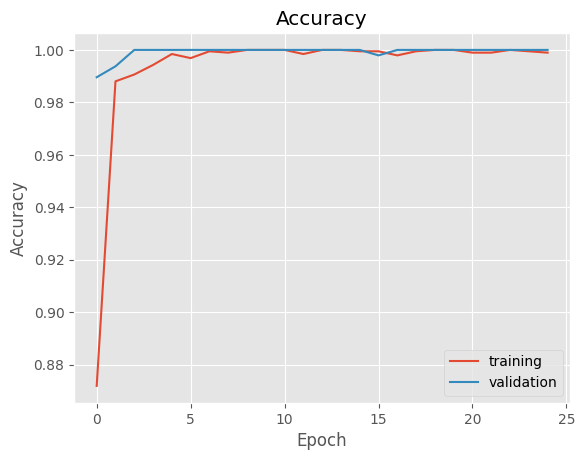

In [15]:
os.makedirs("images", exist_ok=True)

plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, num_epochs), history.history["accuracy"], label="training")
plt.plot(np.arange(0, num_epochs), history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Manual Spot-Check on Real Drawings

The model above only ever saw clean, procedurally generated shapes. Real mouse/touch strokes are messier, so before wiring up the frontend, sanity-check generalization on a handful of real drawings (optional — skips gracefully if none are provided).

To use: draw ~10-15 gestures in `gesture.html` once it exists (or any painting tool), export as PNGs (white strokes on black, like the canvas will produce), and drop them in a `gesture_samples/` folder next to this notebook.


In [16]:
def predict_image(path):
    img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    arr = np.asarray(img, dtype=np.float32).reshape(1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    probs = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))
    return CLASSES[idx], float(probs[idx])


sample_dir = "gesture_samples"
if os.path.isdir(sample_dir) and os.listdir(sample_dir):
    for fname in sorted(os.listdir(sample_dir)):
        label, confidence = predict_image(os.path.join(sample_dir, fname))
        print(f"{fname}: {label} ({confidence:.1%})")
else:
    print(
        f"No samples in '{sample_dir}/' — drop a few real hand-drawn PNGs there "
        "to sanity-check generalization before wiring up the frontend."
    )

No samples in 'gesture_samples/' — drop a few real hand-drawn PNGs there to sanity-check generalization before wiring up the frontend.


## Save Model


In [17]:
# Save using the legacy H5 format which includes architecture metadata
model.save("gesture_model.h5", save_format="h5")

with open("gesture_labels.json", "w") as fp:
    json.dump({"classes": CLASSES}, fp)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Convert Model


In [18]:
# Install tensorflowjs

!pip install tensorflowjs

In [19]:
!tensorflowjs_converter --input_format=keras gesture_model.h5 tfjs_model_gesture

2026-07-07 14:03:28.624926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783433008.647779   11340 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783433008.654431   11340 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783433008.671551   11340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783433008.671594   11340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783433008.671608   11340 computation_placer.cc:177] computation placer alr